# Credit-Card Fraud Detection — a critical reproduction

Reproducing a published fraud-detection tutorial, showing that its near-perfect
numbers come from a data leak (SMOTE applied before the train/test split) plus
metrics that don't work at 0.17% prevalence, then redoing the evaluation honestly.

## 1. Data Loading & Inspection

Load the CSV and check the basics first: shape, types, missing values, duplicates,
and what `Time` actually means. No plots yet.

In [1]:
from pathlib import Path
import sys

import pandas as pd

SEED = 42  # one fixed seed for the whole notebook, so every run gives the same numbers

# Find the repo root by walking up until requirements.txt appears. This way the
# notebook works whether the kernel started in the repo root or in notebook/.
ROOT = Path.cwd().resolve()
while not (ROOT / "requirements.txt").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("not inside the repo, start Jupyter from the project folder")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))  # shared helpers (src/utils.py) from section 2 on

DATA_CSV = ROOT / "data" / "creditcard.csv"
assert DATA_CSV.exists(), f"{DATA_CSV} not found, download it first (see data/README.md)"

pd.set_option("display.max_columns", 40)  # show all 31 columns instead of eliding

In [2]:
df = pd.read_csv(DATA_CSV)
n_raw = len(df)                        # untouched counts, taken before any cleaning
fraud_raw = int(df["Class"].sum())
print(f"rows: {n_raw:,}   columns: {df.shape[1]}")
df.head()

rows: 284,807   columns: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


31 columns: `Time`, `V1`–`V28`, `Amount`, `Class` (1 = fraud). The V-features are
PCA components of undisclosed original features, so they're anonymous and not
interpretable. That will matter later for feature engineering. Everything is
already numeric, nothing to encode.

In [3]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

All `float64` plus one `int64` (`Class`), about 70 MB in memory, so it fits
comfortably. The column names make sense for the problem (`Time`, `Amount`,
`Class`, and the anonymized `V1..V28`), and the index is just a default
`RangeIndex` 0..284,806, there is no natural transaction or card ID to key on.
That is actually relevant later: with no account identifier there is nothing to
accidentally leak through the index, and the row order is capture order, so a
temporal split would be possible even though I use a stratified random one.

In [4]:
print("missing values, whole table:", df.isna().sum().sum())

missing values, whole table: 0


Zero missing values. That basically never happens in a real transaction feed,
which is a reminder that this CSV is the *output* of someone's cleaning + PCA
pipeline we never get to see. Worth a line in the report's reproducibility section.

In [5]:
dups = df.duplicated()  # marks 2nd+ occurrences, i.e. exactly the rows a drop removes
print(f"exact duplicate rows: {dups.sum()}")
print(df.loc[dups, "Class"].value_counts().rename("dropped rows by class"))

df = df.drop_duplicates().reset_index(drop=True)
print(f"kept {len(df):,} of {n_raw:,} rows")

exact duplicate rows: 1081
Class
0    1062
1      19
Name: dropped rows by class, dtype: int64


kept 283,726 of 284,807 rows


1,081 exact duplicates, 19 of them fraud. With 31 continuous columns, two genuinely
different transactions matching on every value isn't plausible, so I drop them.
Main worry: a duplicated row can land in both train and test later and quietly
flatter the score. The counts stay printed above so the decision is visible.

In [6]:
nunique = df.nunique()
constant = nunique[nunique == 1]
print("constant columns:", list(constant.index) if len(constant) else "none")

# the brief asks about duplicated *features* (columns), not just duplicate rows
dup_cols = df.T.duplicated().sum()
print("identical (duplicated) columns:", dup_cols)

print("\nlowest cardinality:")
print(nunique.sort_values().head(3))

constant columns: none


identical (duplicated) columns: 0

lowest cardinality:
Class          2
Amount     32767
Time      124592
dtype: int64


No constant columns, and no two columns are identical either, so there is nothing
to drop yet for being single-valued or a literal duplicate feature. `Class` bottoms
out the cardinality list with 2 values, as it should. (Near-duplicate features are a
softer question I come back to with correlation in section 2 and again on the
training set in section 4.)

In [7]:
t_min, t_max = df["Time"].min(), df["Time"].max()
print(f"Time: min = {t_min:.0f} s, max = {t_max:,.0f} s  ->  {t_max / 3600:.1f} hours (~2 days)")

Time: min = 0 s, max = 172,792 s  ->  48.0 hours (~2 days)


`Time` is just seconds since the first transaction in the capture (max 172,792 s,
almost exactly 48 hours). It is **not** a real timestamp: no clock time, no start
date. Two days is also far too short for weekday or seasonality claims, so any
"temporal analysis" is boxed in from the start.

In [8]:
counts = df["Class"].value_counts()
print(f"original file: {fraud_raw} fraud / {n_raw:,} rows = {fraud_raw / n_raw:.3%}")
print(f"after dedup  : {counts.loc[1]} fraud / {len(df):,} rows = {counts.loc[1] / len(df):.3%}")

original file: 492 fraud / 284,807 rows = 0.173%
after dedup  : 473 fraud / 283,726 rows = 0.167%


492 fraud out of 284,807 in the raw file: **0.173%** prevalence (0.167% after dedup).
This base rate is the most important number in the whole project. A model that
predicts "legit" for everything is already 99.83% accurate, which is why accuracy
can't be the headline metric here (ROC-AUC has its own problem, more on that in the
evaluation section).

## 2. Exploratory Data Analysis

Distributions, segments and correlations, one takeaway per plot. Reusable helpers
live in `src/utils.py` to keep the cells short.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils import fraud_rate_table, plot_fraud_rate

sns.set_theme(style="whitegrid")
# Fixed colors wherever the two classes appear separately: blue = legit, red = fraud.
C_LEGIT, C_FRAUD = "tab:blue", "tab:red"

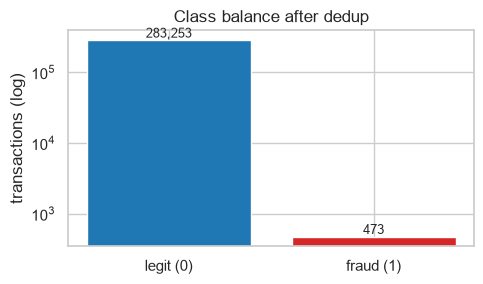

In [10]:
counts = df["Class"].value_counts()

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["legit (0)", "fraud (1)"], counts.loc[[0, 1]], color=[C_LEGIT, C_FRAUD])
ax.set_yscale("log")  # on a linear axis the fraud bar simply doesn't render
for i, v in enumerate(counts.loc[[0, 1]]):
    ax.annotate(f"{v:,}", (i, v), ha="center", va="bottom", fontsize=9)
ax.set_ylabel("transactions (log)")
ax.set_title("Class balance after dedup")
plt.tight_layout()
plt.show()

Without the log axis the fraud bar doesn't render at all (473 vs 283,253). The
practical consequence of a 0.17% base rate is that a review team can only ever
inspect a small queue of alerts per day. A model that floods that queue with false
positives is useless regardless of its recall, which is worth remembering when we
pick metrics in section 6.

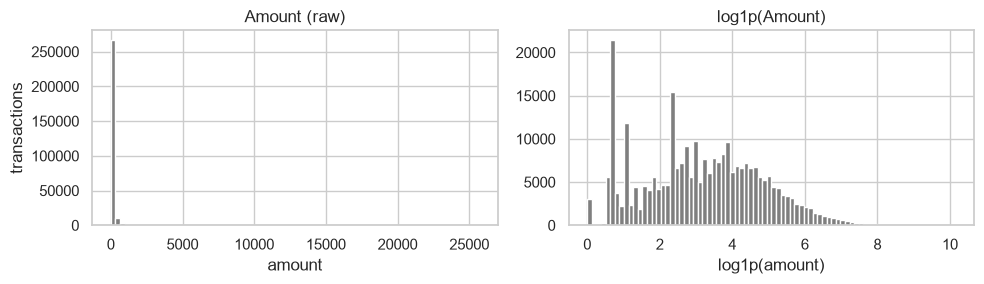

count    283726.00
mean         88.47
std         250.40
min           0.00
25%           5.60
50%          22.00
75%          77.51
max       25691.16
Name: Amount, dtype: float64
zero-amount rows: 1808


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
# gray, not a class color: these histograms mix both classes
axes[0].hist(df["Amount"], bins=80, color="tab:gray")
axes[0].set_title("Amount (raw)")
axes[0].set_xlabel("amount")
axes[0].set_ylabel("transactions")
axes[1].hist(np.log1p(df["Amount"]), bins=80, color="tab:gray")
axes[1].set_title("log1p(Amount)")
axes[1].set_xlabel("log1p(amount)")
plt.tight_layout()
plt.show()

print(df["Amount"].describe().round(2))
print("zero-amount rows:", (df["Amount"] == 0).sum())

Median 22, mean 88, max 25,691. Heavily right-skewed, so the raw histogram is one
spike plus an invisible tail, and `log1p` spreads it into something readable (log1p
rather than plain log because 1,808 rows have Amount = 0). We use the log only for
plotting. For modeling, section 4 scales Amount with `RobustScaler`, which works off
median and IQR and doesn't get dragged around by the tail.

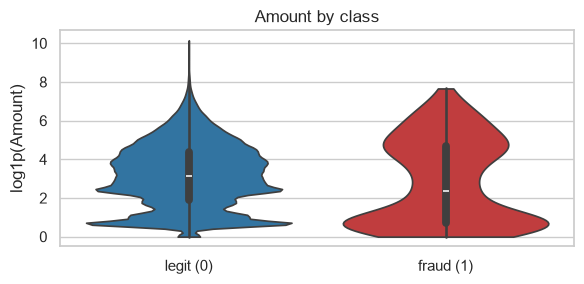

        count    mean  median       max
Class                                  
0      283253   88.41   22.00  25691.16
1         473  123.87    9.82   2125.87


In [12]:
fig, ax = plt.subplots(figsize=(6, 3))
sns.violinplot(x=df["Class"], y=np.log1p(df["Amount"]), hue=df["Class"],
               palette={0: C_LEGIT, 1: C_FRAUD}, legend=False, cut=0, ax=ax)
ax.set_xticks([0, 1], labels=["legit (0)", "fraud (1)"])
ax.set_xlabel("")
ax.set_ylabel("log1p(Amount)")
ax.set_title("Amount by class")
plt.tight_layout()
plt.show()

print(df.groupby("Class")["Amount"].agg(["count", "mean", "median", "max"]).round(2))

Fraud amounts skew small. The median is 9.82 versus 22.00 for legit, and the largest
fraud is 2,126 while legit reaches 25,691. The means point the other way (123.87 vs
88.41) because of a cluster of mid-sized frauds. Either way the boxes overlap
heavily, so Amount alone separates nothing; it only re-weights the odds a little.

In [13]:
q1, q3 = df["Amount"].quantile([0.25, 0.75])
fence = q3 + 1.5 * (q3 - q1)
is_out = df["Amount"] > fence

print(f"upper IQR fence: {fence:.2f}")
print(f"rows above fence: {is_out.sum():,} ({is_out.mean():.2%} of all rows)")
print(f"fraud rate below fence: {df.loc[~is_out, 'Class'].mean():.4%}")
print(f"fraud rate above fence: {df.loc[is_out, 'Class'].mean():.4%}")

upper IQR fence: 185.38
rows above fence: 31,685 (11.17% of all rows)
fraud rate below fence: 0.1531%
fraud rate above fence: 0.2746%


The textbook IQR rule declares 11% of all transactions "outliers" (everything above
185.38), and the fraud rate above the fence is roughly 1.8x the rate below it. So in
this problem outliers are signal, not noise. Deleting them, which is what generic
preprocessing recipes do, would delete part of what we're hunting. This is exactly
the abnormality-detection framing from the course (Mahalanobis distance, Isolation
Forest: both score "how far from the bulk is this point"), and it's why an
unsupervised anomaly model joins the lineup in section 5.

        legit  fraud  total  fraud_rate_%
Amount                                   
0-10    99583    238  99821         0.238
10-50   90272     55  90327         0.061
50-200  64710     98  64808         0.151
200-1k  25762     73  25835         0.283
1k+      2926      9   2935         0.307
      legit  fraud  total  fraud_rate_%
Time                                   
2      3260     48   3308         1.451
3      3470     17   3487         0.488
4      2181     23   2204         1.044


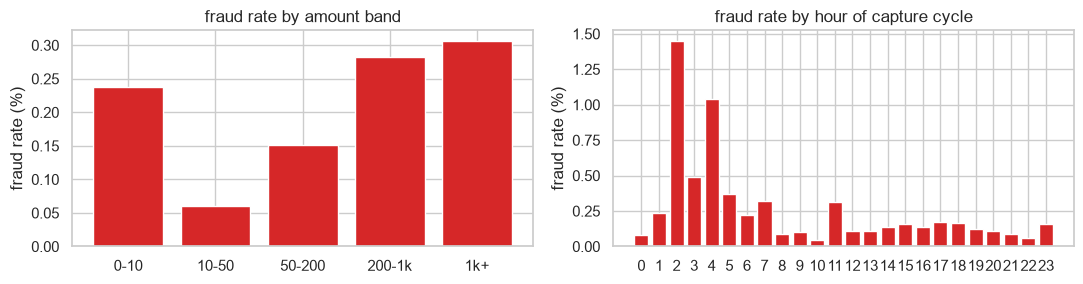

In [14]:
amount_band = pd.cut(df["Amount"], [-0.01, 10, 50, 200, 1000, np.inf],
                     labels=["0-10", "10-50", "50-200", "200-1k", "1k+"])
band_table = fraud_rate_table(amount_band, df["Class"])
print(band_table.round(3))

# hour of the *capture cycle*, not clock time (Time starts at an unknown moment)
hour_of_cycle = ((df["Time"] // 3600) % 24).astype(int)
hour_table = fraud_rate_table(hour_of_cycle, df["Class"])
print(hour_table.loc[[2, 3, 4]].round(3))  # the spike hours, volumes included

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
plot_fraud_rate(band_table, "fraud rate by amount band", ax=axes[0], color=C_FRAUD)
plot_fraud_rate(hour_table, "fraud rate by hour of capture cycle", ax=axes[1], color=C_FRAUD)
plt.tight_layout()
plt.show()

Both tables apply the segmentation idea from the course, comparing *rates* per
segment rather than raw counts, since counts mostly track how busy a segment is.
By amount the risk is U-shaped. The 0-10 band runs at 0.238%, the everyday 10-50
band is safest at 0.061%, then risk climbs with size up to 0.307% for 1k+. Reads
like small test-charges plus big grabs. By hour, hours 2 and 4 of the cycle spike
to 1-1.5% fraud while hour 3 falls back to about 0.5%, still roughly three times
the base rate. The printed table shows all three run on low volume, 2-3.5k rows
each, which looks like the classic night effect: legit traffic goes quiet, fraud
doesn't. The caveat from section 1 applies, hour 0 is the start of the capture,
not midnight.

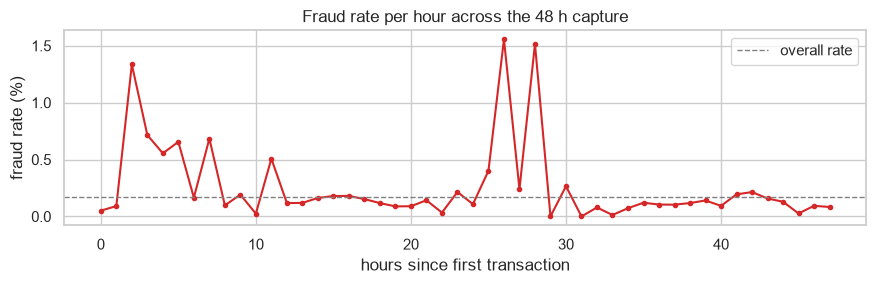

In [15]:
hour_abs = (df["Time"] // 3600).astype(int)  # 0..47 across the two days
rate_48h = df.groupby(hour_abs)["Class"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(rate_48h.index, rate_48h.values, color=C_FRAUD, marker="o", markersize=3)
ax.axhline(100 * df["Class"].mean(), color="gray", linewidth=1, linestyle="--",
           label="overall rate")
ax.set_xlabel("hours since first transaction")
ax.set_ylabel("fraud rate (%)")
ax.set_title("Fraud rate per hour across the 48 h capture")
ax.legend()
plt.tight_layout()
plt.show()

The full timeline tells the same story. Elevated hours cluster around 2-7 on day
one and 26-28 on day two, the same phase of the cycle roughly 24 h apart, and the
rest mostly wobbles around the 0.167% base line (plus one isolated one-hour blip
around hour 11). Consistent with a night effect, but with two days of unanchored
time I can't check it against real clock time, so I note it and won't build
features on it.

### Correlation: which coefficient, and why

Three options from the course, each with a different definition and different
assumptions:

- **Pearson** $r = \dfrac{\operatorname{cov}(X,Y)}{\sigma_X \sigma_Y}$ measures
  *linear* association. Assumes roughly linear, roughly normal data; sensitive to
  outliers and heavy tails. Advantage: directly interpretable ($r^2$ = variance
  explained). Limitation: blind to non-linear structure and easily distorted by a
  fat tail like `Amount`.
- **Spearman** = Pearson computed on the *ranks*. Assumes only monotonicity, so it
  is robust to outliers and non-normal data. Advantage: unaffected by the Amount
  tail. Limitation: still blind to non-monotonic relationships, and degrades with
  many tied values.
- **Kendall** $\tau = \dfrac{C - D}{n(n-1)/2}$ (concordant minus discordant pairs).
  Also rank-based, more conservative, classically preferred for small samples or
  when rank consistency is the point. Limitation: $O(n^2)$ to compute, and its
  small-sample advantage is moot at $n \approx 284{,}000$.

Plan: **Pearson among the V-features**, where the question is literally "are any
two linearly redundant", and **Spearman (with Kendall as a cross-check)** for
Amount/Time against Class, where the heavy tail makes Pearson untrustworthy.

max |Pearson| among V1..V28, after dedup: 0.0189


max |Pearson| among V1..V28, raw file   : 0.000000


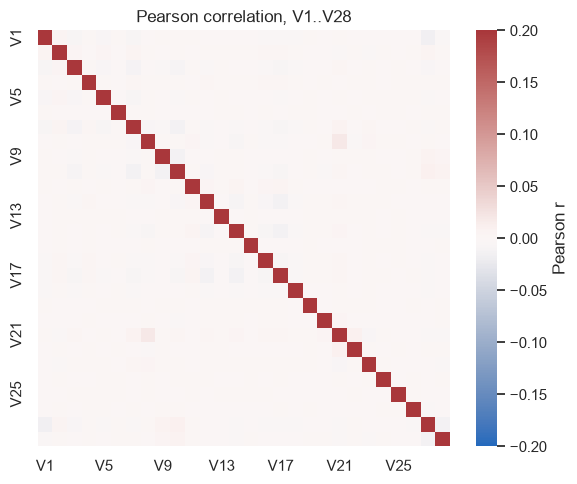

In [16]:
v_cols = [f"V{i}" for i in range(1, 29)]
pearson_v = df[v_cols].corr()
off_diag = pearson_v.mask(np.eye(len(v_cols), dtype=bool))
print(f"max |Pearson| among V1..V28, after dedup: {off_diag.abs().max().max():.4f}")

# same check on the raw file: PCA orthogonality should make this (near-)exactly zero
raw_v = pd.read_csv(DATA_CSV, usecols=v_cols).corr().mask(np.eye(len(v_cols), dtype=bool))
print(f"max |Pearson| among V1..V28, raw file   : {raw_v.abs().max().max():.6f}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pearson_v, cmap="vlag", center=0, vmin=-0.2, vmax=0.2,
            xticklabels=4, yticklabels=4, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Pearson correlation, V1..V28")
plt.tight_layout()
plt.show()

Max |r| = 0.019 over all 378 pairs, so the heatmap is essentially a blank grid, and
the blankness is the finding. PCA components are orthogonal by construction, and the
raw file confirms it, max off-diagonal |r| = 0.000000 there. The 0.019 appears only
because we dropped duplicate rows after the PCA was made. Consequences: no redundant
V-features to prune, and no multicollinearity headache for logistic regression. One
caution, orthogonal is not independent, so the V's can still carry joint signal
about Class.

In [17]:
from scipy import stats

# report r AND its p-value, so we can separate statistical from practical significance
for col in ["Amount", "Time"]:
    pe = stats.pearsonr(df[col], df["Class"])
    sp = stats.spearmanr(df[col], df["Class"])
    kt = stats.kendalltau(df[col], df["Class"])
    print(f"{col:>6} vs Class:  pearson {pe.statistic:+.4f} (p={pe.pvalue:.1e}, "
          f"r^2={pe.statistic**2:.5%})  spearman {sp.statistic:+.4f}  "
          f"kendall {kt.statistic:+.4f}")

Amount vs Class:  pearson +0.0058 (p=2.1e-03, r^2=0.00334%)  spearman -0.0079  kendall -0.0065


  Time vs Class:  pearson -0.0124 (p=4.6e-11, r^2=0.01528%)  spearman -0.0119  kendall -0.0097


Both are essentially zero, and this is the place to separate *statistical* from
*practical* significance. The p-values are basically 0, so a statistician would
call these correlations "significant", but that is only because $n$ is ~284,000,
which makes even a trivial effect pass a significance test. What matters is the
effect size: Pearson $r^2$ for Amount vs Class is about 0.003% (and Time about 0.015%), i.e.
`Amount` explains three-thousandths of one percent of the variation in the label. That is
practically nothing.

Amount is also a small demo of why the coefficient choice matters: Pearson comes
out slightly positive (+0.006) while Spearman is negative (-0.008). A handful of
large frauds drag the linear coefficient up, while rank-wise fraud actually sits at
*smaller* amounts. Kendall agrees with Spearman's sign.

The cybersecurity takeaway is concrete: the two human-readable columns carry almost
no marginal signal, so the naive rules an analyst reaches for first, "block large
amounts" or "flag night-time transactions", would catch essentially no fraud on
their own. Whatever the models learn has to come from the multivariate V-space.

standardized |mean gap|, top 6:
V17    7.68
V14    7.19
V12    6.15
V10    5.07
V16    4.59
V3     4.47
dtype: float64


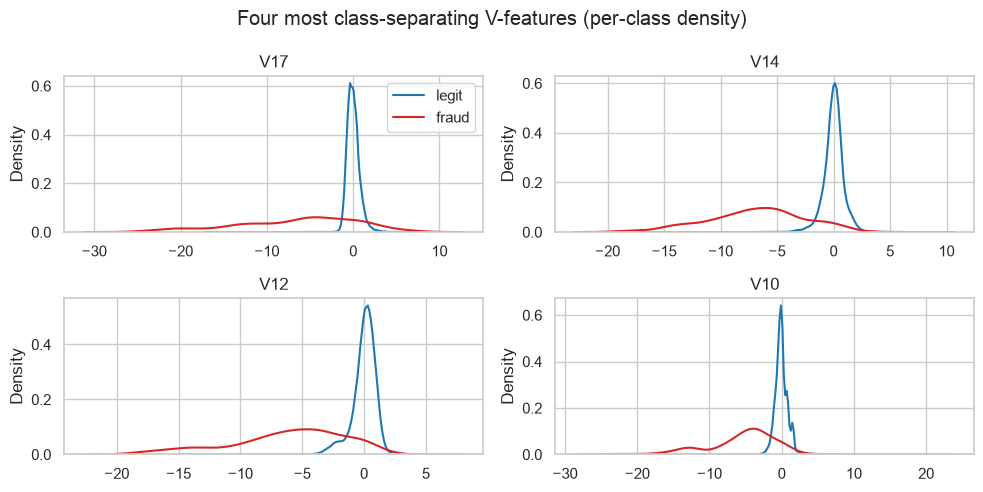

In [18]:
# rank V-features by the gap between class means, in units of each feature's own SD
smd = ((df.loc[df["Class"] == 1, v_cols].mean() - df.loc[df["Class"] == 0, v_cols].mean())
       / df[v_cols].std()).abs().sort_values(ascending=False)
print("standardized |mean gap|, top 6:")
print(smd.head(6).round(2))

top4 = list(smd.index[:4])
fig, axes = plt.subplots(2, 2, figsize=(10, 5))
for ax, col in zip(axes.ravel(), top4):
    sns.kdeplot(df.loc[df["Class"] == 0, col], ax=ax, color=C_LEGIT, label="legit")
    sns.kdeplot(df.loc[df["Class"] == 1, col], ax=ax, color=C_FRAUD, label="fraud")
    ax.set_title(col)
    ax.set_xlabel("")
axes[0, 0].legend()
fig.suptitle("Four most class-separating V-features (per-class density)")
plt.tight_layout()
plt.show()

Rather than dump 28 histograms, I ranked the V's by the gap between class means in
units of each feature's overall SD, and looked at the top four only. V17, V14, V12
and V10 come out ahead with gaps of 5-8 SDs, which is enormous. In all four the
fraud density sits far left of the legit bulk. This is where the model signal
lives, even though none of these features means anything human-readable. Mean gap
as the ranking because it's the simplest defensible answer to "which single
feature separates the classes most".

### How the tutorial handled the imbalance (setup for section 3)

The tutorial does address the 0.17% imbalance, with SMOTE, which is the
course-standard tool. The catch is where it's applied. Their notebook oversamples
the full dataset first and splits into train/test afterwards, and the README's
headline claim (the SMOTE model can "detect 100% of all fraudulent transactions in
the unseen test set", F1 0.998) is measured on that SMOTE-balanced "test" set.
Their own results table already shows F1 dropping to 0.570 when the same model is
scored on the original data. Section 3 reproduces their protocol with our sklearn
models to show the inflation is mechanical, and sections 4-5 then do it properly,
with resampling inside the pipeline on training folds only.

## 3. Reproducing the Tutorial's Reported Result

The tutorial oversamples the ENTIRE dataset with SMOTE and only then splits into
train and test. This section reproduces that protocol on purpose, to show what it
does to the numbers. Every other step is done by the book (scaler fit on train
only, stratified split, fixed seed), so whatever inflation shows up is
attributable to the SMOTE placement alone. None of the leaked data, splits or
models are reused later; only the summary metrics table comes back, in section
6's side-by-side comparison.

In [19]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

from utils import metrics_row

In [20]:
# ============================================================================
# FLAWED REPRODUCTION - do not use for real evaluation.
# This is the tutorial's protocol: SMOTE on the FULL dataset, split afterwards.
# The "test set" it produces is contaminated with synthetic points that were
# interpolated from fraud rows the model also trains on.
# ============================================================================
# SMOTE runs in raw feature units here, exactly as the tutorial has it; scaling
# the full set first would only add a second leak on top.
X_leak, y_leak = SMOTE(random_state=SEED).fit_resample(
    df.drop(columns="Class"), df["Class"])
print(f"after SMOTE: {len(y_leak):,} rows, fraud share {y_leak.mean():.1%}")

# the bug being demonstrated: the split happens AFTER resampling
Xtr_leak, Xte_leak, ytr_leak, yte_leak = train_test_split(
    X_leak, y_leak, test_size=0.3, stratify=y_leak, random_state=SEED)

scaler_leak = RobustScaler().fit(Xtr_leak)  # fit on train only, deliberately clean
Xtr_leak_s = scaler_leak.transform(Xtr_leak)
Xte_leak_s = scaler_leak.transform(Xte_leak)

after SMOTE: 566,506 rows, fraud share 50.0%


In [21]:
leak_models = {
    "LogReg (leaky)": LogisticRegression(max_iter=1000, random_state=SEED),
    "HistGB (leaky)": HistGradientBoostingClassifier(random_state=SEED),
}

results_flawed = {}
for name, model in leak_models.items():
    model.fit(Xtr_leak_s, ytr_leak)
    results_flawed[name] = metrics_row(
        yte_leak,
        model.predict(Xte_leak_s),
        model.predict_proba(Xte_leak_s)[:, 1],
    )

flawed_table = pd.DataFrame(results_flawed).T
print(flawed_table.round(4))

# the rounded 1.0000 recall deserves a closer look before we quote it
cm_leak = confusion_matrix(yte_leak, leak_models["HistGB (leaky)"].predict(Xte_leak_s))
print("\nHistGB confusion matrix on the contaminated test set:")
print(cm_leak)
print(f"HistGB recall, unrounded: {results_flawed['HistGB (leaky)']['recall']:.7f}")

                precision  recall      f1      f2     mcc  roc_auc  pr_auc
LogReg (leaky)     0.9906  0.9673  0.9788  0.9719  0.9584   0.9972  0.9974
HistGB (leaky)     0.9991  1.0000  0.9995  0.9998  0.9990   0.9999  0.9998



HistGB confusion matrix on the contaminated test set:
[[84898    78]
 [    3 84973]]
HistGB recall, unrounded: 0.9999647


These are leaderboard numbers, and they have the same shape as the tutorial's
headline. Its README says the model can "detect 100% of all fraudulent
transactions in the unseen test set" at F1 0.998; our HistGB prints recall 1.0000
and F1 0.9995. The confusion matrix above shows that 1.0000 is a display artifact,
3 of 84,976 test frauds still slip through. The tutorial's results table has the
same wrinkle, listing recall 0.9998 under a "100%" headline. Leakage inflates the
number and rounding finishes the job. Their score comes from a Keras neural
network, ours from plain sklearn models (I use HistGradientBoosting here only
because plain GradientBoosting is painfully slow on the 566k-row oversampled set;
the model choice is not the point), so the inflation is a property of the protocol,
whatever model you drop in.

Two things happen mechanically. First, SMOTE builds each synthetic fraud by
interpolating between a real fraud and one of its nearest fraud neighbours, so
splitting afterwards plants near-copies of training rows in the test set, and the
model is graded on data it has effectively already seen. Second, the "test" set
is half fraud instead of 0.17%, and at 50/50 prevalence precision is high almost
by construction, while the same error rate at the real base rate would crater it.
The tutorial demonstrates that second effect on itself, its F1 falls to 0.570 the
moment the model is scored on the original data. Section 5 runs the same kind of
models under an honest protocol, and no `*_leak` variable appears past this
section.

## 4. Feature Engineering (leakage-free)

From here on we do it right, and the first rule is boring but absolute: split
before anything else. No resampling, no scaling, no statistic of any kind gets
computed on data that includes the test rows. The test set exists only to be
transformed with train-fitted parameters and scored, once, in section 6.

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

X = df.drop(columns="Class")
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED)

print(f"train: {len(y_train):,} rows, {int(y_train.sum())} fraud ({y_train.mean():.4%})")
print(f"test : {len(y_test):,} rows, {int(y_test.sum())} fraud ({y_test.mean():.4%})")

train: 198,608 rows, 331 fraud (0.1667%)
test : 85,118 rows, 142 fraud (0.1668%)


Stratifying on `Class` keeps both sides at the same 0.167% prevalence, which
matters when the whole positive class is 473 rows. A quick word on encoding,
since the course brief asks which encoder to use and why: there is nothing to
encode. Every predictor is numeric (V1..V28 are PCA components, Amount is money,
Time is seconds). If a categorical column existed, say merchant category, the
course recipe would apply, one-hot for low cardinality and target encoding for
high cardinality. Here the pipeline simply has no encoder, and that is a
decision, not an oversight.

In [23]:
# scale only the two raw columns. V1..V28 are PCA outputs: zero-centered and all
# unit-order (train SDs 0.33-1.95) against Time's SD of ~47,000 and Amount's ~240,
# so trees don't care and regularized LogReg is barely affected; rescaling them
# would only erase the PCA variance ordering.
preprocess = ColumnTransformer(
    [("scale", RobustScaler(), ["Time", "Amount"])],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

X_train_prep = pd.DataFrame(preprocess.fit_transform(X_train),
                            columns=preprocess.get_feature_names_out(),
                            index=X_train.index)
X_test_prep = pd.DataFrame(preprocess.transform(X_test),
                           columns=preprocess.get_feature_names_out(),
                           index=X_test.index)

for col in ["Time", "Amount"]:
    print(f"scaled {col}: train median {X_train_prep[col].median():+.4f}, "
          f"test median {X_test_prep[col].median():+.4f}")

scaled Time: train median +0.0000, test median -0.0041
scaled Amount: train median +0.0000, test median -0.0025


`RobustScaler` centers on the median and scales by the IQR, so the heavy Amount
tail from section 2 can't drag the scaling around the way it would drag a mean
and standard deviation. The printed medians are the leakage check made visible.
Train medians are exactly 0 because the scaler was fit there; test medians land
close to 0 but not on it (-0.0041 and -0.0025), because the test set is only
*transformed* with the train-fitted parameters. Section 5 reuses this
preprocessing recipe inside its pipelines. I use a fresh `clone(preprocess)` per
model, since I noticed pipelines that share one instance would let a later fit
(the Isolation Forest trains on legit rows only) overwrite an earlier model's
scaler. These two prepared frames stay inspection-only.

In [24]:
# redundancy check, on the training set only
v_cols = [f"V{i}" for i in range(1, 29)]
v_max = X_train[v_cols].corr().mask(np.eye(len(v_cols), dtype=bool)).abs().max().max()
print(f"max |Pearson| among V-features, train only: {v_max:.4f}")

pe = X_train["Amount"].corr(np.log1p(X_train["Amount"]))
sp = X_train["Amount"].corr(np.log1p(X_train["Amount"]), method="spearman")
print(f"Amount vs log1p(Amount): pearson {pe:.3f}, spearman {sp:.3f}")

max |Pearson| among V-features, train only: 0.0436
Amount vs log1p(Amount): pearson 0.566, spearman 1.000


No near-duplicate V-features on the training set either (max |r| = 0.0436, a bit
above section 2's full-data 0.019 purely because the sample is smaller). The
log1p(Amount) column the spec left optional gets skipped, for two different
reasons depending on the model. Spearman between Amount and log1p(Amount) is
exactly 1.000, so for trees the transform is a strict no-op, the splits come out
identical. For logistic regression it genuinely would be a new nonlinear feature
(the Pearson between the two is only 0.566, the skew showing up again), but
section 2 showed Amount carries almost no marginal signal in either direction
(Spearman -0.008 vs Class), and RobustScaler already tames the tail. A nonlinear
recoding of a near-useless column isn't worth a feature slot.

### What's left to engineer here? Almost nothing, and that feeds the report.

V1..V28 are anonymized PCA components. No units, no meaning, no domain features
to build from them, and no way to tell a fraud analyst *why* a transaction was
flagged. The only raw columns are Amount and Time, and section 2 showed both are
marginally near-useless. There isn't even a card or account identifier to group
by. With the real data I would want transaction velocity (time since the card's
previous transaction), merchant category, and geo distance from the previous
transaction, all standard fraud-ops features, and none of them constructible
here. The tutorial never mentions this ceiling. It presents a dataset where
feature engineering is impossible as if nothing were missing, which is part of
the critique.

**Feature selection and dimensionality reduction (deliberately skipped).** With 30
orthogonal features over ~283,000 rows there is no curse of dimensionality and no
real overfitting pressure, so I keep all features rather than prune. The redundancy
check above already rules out literally duplicated or collinear columns. A tool
like Predictive Power Score would add nothing here: the V-features are orthogonal
PCA components (max |Pearson| 0.019), so pairwise predictive power is ~0 by
construction, and the standardized mean-gap ranking from section 2 already answers
"which features separate the classes". Re-applying PCA/UMAP would be circular, the
inputs are already principal components, so it would only re-mix decorrelated axes
and cost more interpretability. The small ablation below checks that the one
transformation I *do* apply (scaling) is the right call, with numbers rather than
assertion.

In [25]:
# Does the scaler choice actually matter? Compare RobustScaler vs StandardScaler
# vs no scaling, on the held-out test set, for the linear model (scale-sensitive)
# and the forest (scale-invariant). Evidence, not assertion.
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier as _RF
from sklearn.linear_model import LogisticRegression as _LR
from imblearn.pipeline import Pipeline as _ImbPipe
from imblearn.over_sampling import SMOTE as _SMOTE
from sklearn.base import clone as _clone
from sklearn.pipeline import Pipeline as _Pipe
from utils import metrics_row as _mrow
import warnings
from sklearn.exceptions import ConvergenceWarning

def _prep(scaler):
    if scaler is None:
        return ColumnTransformer([], remainder='passthrough',
                                 verbose_feature_names_out=False)
    return ColumnTransformer([('s', scaler, ['Time', 'Amount'])],
                             remainder='passthrough', verbose_feature_names_out=False)

_scalers = {'RobustScaler': RobustScaler(), 'StandardScaler': StandardScaler(),
            'none': None}
_rows = []
with warnings.catch_warnings():
    # unscaled LogReg hits the iteration cap; that non-convergence is itself the
    # argument for scaling, and we note it in the markdown rather than spam the output
    warnings.simplefilter('ignore', ConvergenceWarning)
    for _name, _sc in _scalers.items():
        _lr = _ImbPipe([('prep', _prep(_sc)), ('smote', _SMOTE(random_state=SEED)),
                        ('clf', _LR(max_iter=1000, random_state=SEED))]).fit(X_train, y_train)
        _rf = _Pipe([('prep', _prep(_sc)),
                        ('clf', _RF(n_estimators=100, class_weight='balanced',
                                    random_state=SEED, n_jobs=-1))]).fit(X_train, y_train)
        for _mname, _m in [('LogReg+SMOTE', _lr), ('RandomForest', _rf)]:
            _r = _mrow(y_test, _m.predict(X_test), _m.predict_proba(X_test)[:, 1])
            _rows.append({'scaler': _name, 'model': _mname,
                          'F1': round(_r['f1'], 3), 'MCC': round(_r['mcc'], 3),
                          'PR_AUC': round(_r['pr_auc'], 3)})
ablation = pd.DataFrame(_rows).set_index(['model', 'scaler'])
print(ablation.to_string())

                                F1    MCC  PR_AUC
model        scaler                              
LogReg+SMOTE RobustScaler    0.097  0.209   0.689
RandomForest RobustScaler    0.830  0.836   0.807
LogReg+SMOTE StandardScaler  0.095  0.207   0.691
RandomForest StandardScaler  0.830  0.836   0.807
LogReg+SMOTE none            0.191  0.305   0.721
RandomForest none            0.827  0.832   0.816


The ablation is almost a null result, and that is exactly the point. The random
forest is identical to three decimals across RobustScaler, StandardScaler and no
scaling (F1 0.830 / 0.830 / 0.827), just as a tree should be, it only cares about
split order. The logistic regression is a little more interesting: RobustScaler and
StandardScaler give essentially the same result (F1 0.097 vs 0.095), and unscaled it
actually doesn't even converge in 1000 iterations. That non-convergence, not any F1
gap, is the real reason to scale a linear model, the optimizer needs comparable
ranges. So scaling `Time` and `Amount` is the right call, the *choice* of scaler
barely matters, and either way it moves almost nothing, which fits a dataset that is
already 28/30 pre-scaled PCA components. RobustScaler is the principled pick for a
heavy tail; I am not pretending it wins on the numbers.

## 5. Model Training (correct protocol)

Four models, one rule: they all get judged on the same untouched test set from
section 4, and anything fit-like (scaling, resampling, the model itself) happens
inside `fit`, on training data only. Two are supervised (logistic regression and a
random forest) and two are unsupervised anomaly detectors (isolation forest and a
Mahalanobis-distance baseline), which ties directly to the course's abnormality-
detection material. Each pipeline gets its own `clone(preprocess)`, a fresh copy,
so that fitting one model's scaler can never overwrite another's (sklearn pipelines
re-fit their steps in place rather than copying them). This section only trains and
predicts; all the scoring happens side by side in section 6.

In [26]:
from sklearn.base import clone
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

model_outputs = {}  # name -> {'pred': hard 0/1, 'score': continuous, for the AUCs}

**Logistic regression, the interpretable baseline.** The imblearn pipeline is
the fix this whole project is about: SMOTE sits between the scaler and the
classifier, so it runs during `fit` on the training side only and the test set
never contains a synthetic point. Same resampler as section 3, opposite
placement.

In [27]:
pipe_lr = ImbPipeline([
    ("prep", clone(preprocess)),
    ("smote", SMOTE(random_state=SEED)),  # applied inside fit only
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
])
pipe_lr.fit(X_train, y_train)

model_outputs["LogReg + SMOTE (correct)"] = {
    "pred": pipe_lr.predict(X_test),
    "score": pipe_lr.predict_proba(X_test)[:, 1],
}
print(f"LogReg converged after {pipe_lr.named_steps['clf'].n_iter_[0]} iterations")

LogReg converged after 53 iterations


**Random forest, the stronger supervised model.** No SMOTE here.
`class_weight='balanced'` reweights the 0.167% minority inside the trees
instead, so the imbalance is handled without touching the data at all.

In [28]:
pipe_rf = Pipeline([
    ("prep", clone(preprocess)),
    ("clf", RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                   random_state=SEED, n_jobs=-1)),
])
pipe_rf.fit(X_train, y_train)

model_outputs["RandomForest balanced (correct)"] = {
    "pred": pipe_rf.predict(X_test),
    "score": pipe_rf.predict_proba(X_test)[:, 1],
}

# names must come from the fitted transformer, which reorders columns
feat_names = pipe_rf.named_steps["prep"].get_feature_names_out()
importances = pd.Series(pipe_rf.named_steps["clf"].feature_importances_,
                        index=feat_names).sort_values(ascending=False)
print("top-5 feature importances:")
print(importances.head(5).round(3))

top-5 feature importances:
V14    0.216
V12    0.151
V4     0.098
V10    0.094
V17    0.069
dtype: float64


The forest's top features (V14, V12, V4, V10, V17) overlap almost perfectly
with the mean-gap ranking from section 2, which found V17, V14, V12, V10. Two
independent ways of asking "where is the signal" give the same answer, and
none of it is interpretable, since these are anonymous PCA components.

**Isolation forest, the anomaly detector from the abnormality-detection
lectures.** It never trains on a fraud label as a target, though labels do two
quiet jobs here: they pick the clean rows it fits on, and they set the
contamination rate. Strictly that makes this novelty detection, semi-supervised
rather than blind unsupervised. The model learns what normal looks like from
legitimate training rows and scores how easily each test point isolates.
Contamination positions the score cutoff so that about 0.167% of the clean
training rows would be flagged, roughly the real base rate; on the mixed test
set it flags a bit more (0.22%), which is what you'd expect when actual
anomalies are present and the threshold was calibrated on clean rows only.

In [29]:
pipe_iso = Pipeline([
    ("prep", clone(preprocess)),
    ("clf", IsolationForest(contamination=float(y_train.mean()),
                            random_state=SEED, n_jobs=-1)),
])
# novelty framing: everything it learns, scaler included, comes from legit rows
pipe_iso.fit(X_train[y_train == 0])

model_outputs["IsolationForest novelty (correct)"] = {
    "pred": (pipe_iso.predict(X_test) == -1).astype(int),  # -1 = anomaly -> fraud
    "score": -pipe_iso.decision_function(X_test),          # higher = more anomalous
}
n_flagged = model_outputs["IsolationForest novelty (correct)"]["pred"].sum()
print(f"flagged {n_flagged:,} of {len(X_test):,} test rows as anomalies")

flagged 191 of 85,118 test rows as anomalies


**Mahalanobis-distance baseline, the second unsupervised model.** This is the
abnormality-detection idea in its most classical form, straight from the
positive-definite / ellipsoid lecture. I fit a mean vector and covariance matrix
on the scaled *legitimate* training rows only, then score each test row by its
squared Mahalanobis distance $d^2 = (x-\mu)^\top \Sigma^{-1} (x-\mu)$ from that
normal cloud, and flag anything past the $\chi^2$ 0.99 cutoff. Because the
V-features are orthogonal PCA components, $\Sigma$ is nearly diagonal and $d^2$
is essentially a sum of squared z-scores, a textbook fit for this data.

In [30]:
from scipy.stats import chi2

# fit the normal model on scaled legit training rows only (no fraud labels used
# except to pick the clean rows, same novelty framing as the isolation forest)
legit_prep = X_train_prep[y_train.values == 0]
mu = legit_prep.mean().values
cov = np.cov(legit_prep.values, rowvar=False)
inv_cov = np.linalg.pinv(cov)  # pseudo-inverse for numerical safety

def mahalanobis_sq(frame):
    d = frame.values - mu
    return np.einsum('ij,jk,ik->i', d, inv_cov, d)

maha_test = mahalanobis_sq(X_test_prep)
cutoff = chi2.ppf(0.99, df=len(mu))  # flag the 1% most extreme under a normal model
model_outputs["Mahalanobis (unsup)"] = {
    "pred": (maha_test > cutoff).astype(int),
    "score": maha_test,
}
print(f"chi-square cutoff (df={len(mu)}): {cutoff:.1f}")
print(f"flagged {int((maha_test > cutoff).sum()):,} of {len(X_test):,} test rows")

chi-square cutoff (df=30): 50.9
flagged 5,636 of 85,118 test rows


Everything the evaluation needs now sits in `model_outputs`: for each of the four
models, the hard predictions plus a continuous score. Section 6 scores all of it in
one table, side by side with the flawed run from section 3.

**A quick cross-validation sanity check.** The numbers above come from one fixed
split. To make sure they are not a lucky split, I run 5-fold stratified CV for
the two supervised pipelines on the training data. SMOTE stays *inside* the
pipeline, so each fold still resamples only its own training part, no leak. The
mean should sit close to the held-out numbers with a small spread.

In [31]:
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_models = {
    "LogReg + SMOTE": ImbPipeline([("prep", clone(preprocess)),
                                   ("smote", SMOTE(random_state=SEED)),
                                   ("clf", LogisticRegression(max_iter=1000, random_state=SEED))]),
    "RandomForest": Pipeline([("prep", clone(preprocess)),
                             ("clf", RandomForestClassifier(n_estimators=100,
                                     class_weight="balanced", random_state=SEED, n_jobs=-1))]),
}
for name, pipe in cv_models.items():
    sc = cross_validate(pipe, X_train, y_train, cv=cv,
                        scoring=["f1", "average_precision"], n_jobs=-1)
    print(f"{name:15s} F1 {sc['test_f1'].mean():.3f} +/- {sc['test_f1'].std():.3f}   "
          f"PR-AUC {sc['test_average_precision'].mean():.3f} +/- "
          f"{sc['test_average_precision'].std():.3f}")

LogReg + SMOTE  F1 0.100 +/- 0.006   PR-AUC 0.752 +/- 0.040


RandomForest    F1 0.851 +/- 0.022   PR-AUC 0.840 +/- 0.030


## 6. Evaluation

One table, every model, leaky and correct side by side. This is the payoff of
the whole notebook, so the metric choices get justified right after it.

In [32]:
results_correct = {
    name: metrics_row(y_test, out["pred"], out["score"])
    for name, out in model_outputs.items()
}

comparison = pd.concat([pd.DataFrame(results_correct).T, flawed_table])
comparison.insert(0, "protocol",
                  ["correct"] * len(results_correct) + ["LEAKY"] * len(flawed_table))
print(comparison.round(3).to_string())

                                  protocol  precision  recall     f1     f2    mcc  roc_auc  pr_auc
LogReg + SMOTE (correct)           correct      0.052   0.880  0.097  0.209  0.209    0.966   0.689
RandomForest balanced (correct)    correct      0.946   0.739  0.830  0.773  0.836    0.941   0.807
IsolationForest novelty (correct)  correct      0.204   0.275  0.234  0.257  0.235    0.940   0.128
Mahalanobis (unsup)                correct      0.021   0.845  0.042  0.097  0.128    0.951   0.417
LogReg (leaky)                       LEAKY      0.991   0.967  0.979  0.972  0.958    0.997   0.997
HistGB (leaky)                       LEAKY      0.999   1.000  1.000  1.000  0.999    1.000   1.000


Read the LogReg rows first, because it is the same algorithm twice. Leaky
protocol: F1 0.979. Honest protocol: F1 0.097. Nothing about the model changed,
only where SMOTE ran, and 0.88 of F1 evaporates. The honest LogReg is not even
bad at finding fraud (recall 0.880), it just drowns the signal in false alarms,
as the confusion matrix below makes concrete. The honest headline is the random
forest: F1 0.830, MCC 0.836, PR-AUC 0.807, right where leakage-aware studies of
this dataset land (arXiv:2506.02703, arXiv:2412.07437; both cited in the
report). Next to the leaky HistGB's 0.9995 that looks disappointing, and that is
the correct reaction: one number is an honest measurement, the other is an
artifact.

In [33]:
# the all-legit baseline everyone implicitly compares against
trivial_acc = (y_test == 0).mean()
print(f"accuracy of predicting 'legit' for every row: {trivial_acc:.4%}")

accuracy of predicting 'legit' for every row: 99.8332%


### Every metric: definition and what it means for fraud

The brief asks for the maths and the meaning of each metric, so, with TP/FP/TN/FN
the four confusion-matrix counts and a positive = fraud:

| Metric | Formula | What it measures | Why it matters for fraud |
|---|---|---|---|
| Precision | $\frac{TP}{TP+FP}$ | of flagged transactions, the share truly fraud | low precision = analysts drowning in false alarms |
| Recall | $\frac{TP}{TP+FN}$ | of actual frauds, the share caught | a miss = fraud goes through, money lost |
| $F_1$ | $\frac{2PR}{P+R}$ | harmonic mean of the two | one number balancing misses vs false alarms |
| $F_\beta$ ($\beta{=}2$) | $\frac{(1+\beta^2)PR}{\beta^2 P + R}$ | weights recall $\beta^2{=}4\times$ precision | a missed fraud costs more than a false alarm |
| MCC | $\frac{TP\cdot TN - FP\cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$ | correlation of prediction and truth, in $[-1,1]$ | honest under 600:1 imbalance, uses all four cells |
| Accuracy | $\frac{TP+TN}{N}$ | overall fraction correct | useless here (see below) |
| ROC-AUC | $P(\text{score}_{\text{fraud}} > \text{score}_{\text{legit}})$ | ranking quality across all thresholds | over-optimistic under heavy imbalance |
| PR-AUC | $\sum_n (R_n - R_{n-1})\,P_n$ | area under precision-recall curve | the honest headline at 0.17% prevalence |

**Which I trust here, and which I don't.** Accuracy is out because the base rate
decides it: predicting "legit" for every row scores 99.83% while catching zero
fraud. ROC-AUC stays in the table but can't be the headline, and my own results
show why: the random forest and the isolation forest have nearly identical ROC-AUC
(0.941 vs 0.940) yet their PR-AUCs differ six-fold (0.807 vs 0.128). ROC-AUC
conditions on class, so the ~85,000 legit rows barely move it; PR-AUC lives in
precision space, where every false alarm hurts. **PR-AUC is not on the course's
standard list** and I add it deliberately, because at this prevalence it is the
metric that actually separates the models. MCC = 0.836 for the forest means strong
prediction-truth agreement that, unlike F1, cannot be faked by always predicting
the majority, because it also credits the true negatives. I keep F1 as the
headline for the leaky-vs-honest comparison only because F1 is the tutorial's own
chosen metric, so the collapse is measured on their ground; F2, MCC and PR-AUC are
the ones I'd actually deploy against.

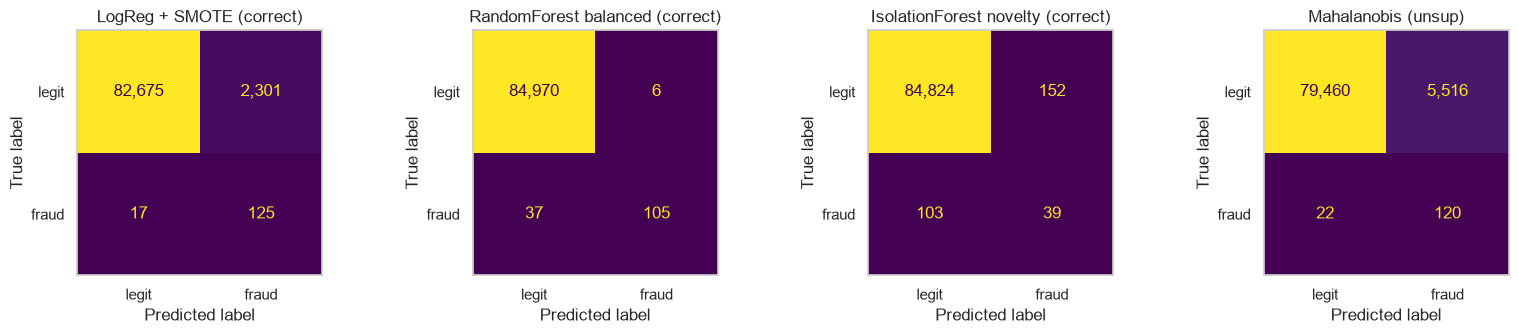

In [34]:
from utils import plot_confusion

fig, axes = plt.subplots(1, len(model_outputs),
                         figsize=(4 * len(model_outputs), 3.5))
for ax, (name, out) in zip(axes, model_outputs.items()):
    plot_confusion(y_test, out["pred"], name, ax)
plt.tight_layout()
plt.show()

Four very different ways to be imperfect. LogReg catches 125 of 142 frauds but
raises 2,301 false alarms, an unworkable review queue. The forest catches 105 with
only 6 false alarms, clearly the best operating point. The two unsupervised anomaly
models never saw a fraud label and behave very differently from each other at their
default cutoffs: the isolation forest flags 191 rows (39 real frauds), while the
Mahalanobis baseline at the chi-square 0.99 cutoff is far looser, flagging ~5,600
rows to catch ~120 frauds, so its recall is high (0.85) but its precision is tiny.
The fairer way to compare the anomaly models is by ranking (PR-AUC), where
Mahalanobis (0.42) actually edges out the isolation forest (0.13), a reminder that
a simple parametric model can beat a fancier one. Either way both are well behind
the supervised forest once labels are available.

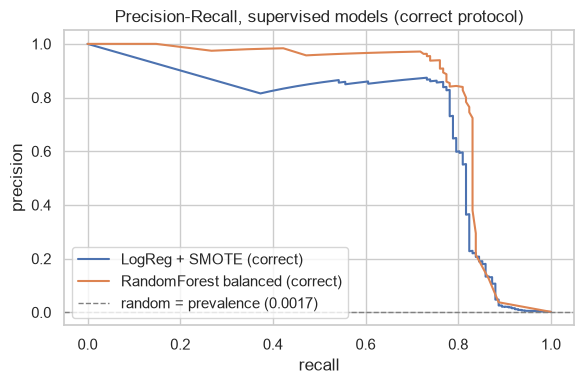

In [35]:
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(6, 4))
for name in ["LogReg + SMOTE (correct)", "RandomForest balanced (correct)"]:
    prec, rec, _ = precision_recall_curve(y_test, model_outputs[name]["score"])
    ax.plot(rec, prec, label=name)
ax.axhline(y_test.mean(), linestyle="--", color="gray", linewidth=1,
           label=f"random = prevalence ({y_test.mean():.4f})")
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("Precision-Recall, supervised models (correct protocol)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

The PR curve, not the ROC curve, is where this problem actually lives. The forest
dominates everywhere and holds precision near 1.0 out to recall around 0.75; both
curves then fall off a cliff, because the last few frauds look like normal
traffic. The subtle one: the honest LogReg's *curve* is respectable, even though
its table row shows precision 0.052. That's an operating-point problem, not a
ranking problem. SMOTE trains the model on 50/50 data, which shifts the intercept
so the default 0.5 cutoff lands far past the cliff (recall 0.880, precision
0.052). The dashed line is a random classifier (precision = prevalence, 0.0017),
which is why a small-looking PR-AUC like the isolation forest's 0.128 is still
some 75x above chance.

## 7. Error Analysis

The random forest is the model we'd actually deploy, so its mistakes are the
ones worth reading. 37 missed frauds and 6 false alarms, row by row.

In [36]:
rf_out = model_outputs["RandomForest balanced (correct)"]
rf_pred, rf_score = rf_out["pred"], rf_out["score"]

missed = X_test[(y_test == 1) & (rf_pred == 0)]        # false negatives
caught = X_test[(y_test == 1) & (rf_pred == 1)]        # true positives
false_alarms = X_test[(y_test == 0) & (rf_pred == 1)]  # false positives
print(f"missed: {len(missed)}   caught: {len(caught)}   false alarms: {len(false_alarms)}")

print("\nAmount, caught vs missed fraud:")
print(pd.DataFrame({"caught": caught["Amount"].describe(),
                    "missed": missed["Amount"].describe()}).round(2))

print("\nfalse-alarm amounts:", false_alarms["Amount"].round(2).tolist())

missed_hours = ((missed["Time"] // 3600) % 24).astype(int)
caught_hours = ((caught["Time"] // 3600) % 24).astype(int)
print("\nmissed-fraud hour counts:", missed_hours.value_counts().sort_index().to_dict())
print(f"share in the night window (hours 2-7): "
      f"missed {missed_hours.isin(range(2, 8)).mean():.0%}, "
      f"caught {caught_hours.isin(range(2, 8)).mean():.0%}")
print("false-alarm hours:", sorted(((false_alarms['Time'] // 3600) % 24).astype(int).tolist()))

v_gap = (caught[v_cols].mean() - missed[v_cols].mean()).abs().sort_values(ascending=False)
print("\nlargest V-feature gaps, caught vs missed:")
print(v_gap.head(5).round(2))

# the three hardest misses: lowest RF scores among the missed frauds
missed_scored = missed.assign(rf_score=rf_score[(y_test == 1) & (rf_pred == 0)])
print("\nthree hardest-missed frauds (lowest RF score):")
print(missed_scored.nsmallest(3, "rf_score")[["Amount", "V17", "V14", "V12", "V10", "rf_score"]].round(2))

missed: 37   caught: 105   false alarms: 6

Amount, caught vs missed fraud:
        caught   missed
count   105.00    37.00
mean    130.48   166.96
std     255.79   370.93
min       0.00     0.00
25%       1.00     1.00
50%      30.39     3.79
75%     106.55   105.99
max    1389.56  1809.68

false-alarm amounts: [109.9, 1.0, 1.52, 8.99, 0.76, 1.0]

missed-fraud hour counts: {0: 1, 1: 1, 2: 2, 3: 1, 4: 3, 7: 1, 9: 1, 10: 2, 12: 4, 13: 2, 14: 3, 15: 1, 16: 2, 17: 4, 18: 3, 19: 2, 20: 2, 22: 2}
share in the night window (hours 2-7): missed 19%, caught 30%
false-alarm hours: [4, 4, 11, 11, 20, 21]

largest V-feature gaps, caught vs missed:
V17    7.38
V3     7.10
V10    6.25
V14    5.65
V7     5.64
dtype: float64

three hardest-missed frauds (lowest RF score):
        Amount   V17   V14   V12   V10  rf_score
72475     1.79 -0.15 -0.93  0.04  1.01       0.0
231118    8.00  2.35 -3.69 -0.34 -0.89       0.0
50317     1.00 -0.21 -0.50  0.92 -1.48       0.0


Three patterns in the misses. First, amount: the median missed fraud is 3.79
against 30.39 for caught ones, so the model loses the tiny test-charge frauds,
yet the missed *mean* is higher (166.96) because one 1,809.68 fraud slipped
through, the single most expensive mistake in the test set. Second, timing: only
19% of misses fall in the night window (hours 2-7) that section 2 flagged,
against 30% of caught frauds, so the "easy" night fraud gets caught and the
hard cases hide in daytime traffic. Third, the V-space story: caught and missed
frauds differ most on V17, V3, V10, V14, and three of those (V17, V10, V14) are
exactly the features carrying the fraud signal everywhere else in this notebook.
The missed frauds are missed because they sit close to normal in the directions
the model watches. The six false alarms are mostly small amounts (five under 10)
spread over unrelated hours; six rows is too few for pattern statistics, and a
reviewer would clear them in minutes.

In [37]:
# what happens if we trade precision for recall by lowering the cutoff
from sklearn.metrics import fbeta_score, precision_score, recall_score

for t in [0.5, 0.3, 0.2, 0.1]:
    pred_t = (rf_score >= t).astype(int)
    print(f"threshold {t:.1f}:  precision {precision_score(y_test, pred_t):.3f}  "
          f"recall {recall_score(y_test, pred_t):.3f}  "
          f"F2 {fbeta_score(y_test, pred_t, beta=2):.3f}  "
          f"flags {pred_t.sum()}")

threshold 0.5:  precision 0.946  recall 0.739  F2 0.773  flags 111
threshold 0.3:  precision 0.901  recall 0.768  F2 0.791  flags 121
threshold 0.2:  precision 0.841  recall 0.782  F2 0.793  flags 132
threshold 0.1:  precision 0.678  recall 0.831  F2 0.795  flags 174


Would I move the threshold? Yes, down. A missed fraud costs the transaction
amount plus a chargeback and reputational damage; a false alarm costs an analyst
a few minutes and, at worst, one annoyed customer with a declined card. Dropping
the cutoff from 0.5 to 0.1 raises recall from 0.739 to 0.831, 13 more frauds
caught, for 63 extra flags on this 30% test sample. Scaled to full two-day
traffic that is roughly 100 extra alerts a day, still a queue a small review
team clears comfortably. F2, the metric aligned with this cost structure,
agrees, rising from 0.773 to 0.795. In production the cutoff would be set from
actual money (expected fraud loss vs review cost per alert), but the direction
is not in doubt.

**Putting a number on "move the threshold down".** The argument above is
qualitative; here it is as money. If a missed fraud costs its transaction amount
and a false alarm costs a fixed review effort (I use 3 currency units, a few
minutes of an analyst), the total cost is a function of the cutoff. Minimising it
gives a defensible operating point instead of a hunch.

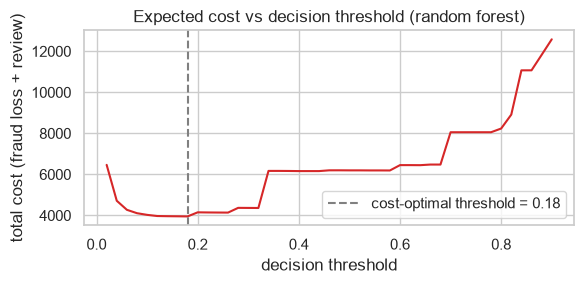

cost-optimal threshold: 0.18  (default 0.5 costs 1.57x the optimum)


In [38]:
amounts_test = X_test["Amount"].values
y_arr = y_test.values
review_cost = 3.0  # assumed cost per reviewed alert, same currency unit as Amount

grid = np.linspace(0.02, 0.9, 45)
costs = []
for t in grid:
    flagged = rf_score >= t
    fn_loss = amounts_test[(y_arr == 1) & (~flagged)].sum()   # missed fraud = money out
    fp_cost = review_cost * int(((y_arr == 0) & flagged).sum())  # false alarms = review time
    costs.append(fn_loss + fp_cost)
costs = np.array(costs)
best_t = grid[costs.argmin()]
cost_at_half = costs[np.argmin(np.abs(grid - 0.5))]

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(grid, costs, color=C_FRAUD)
ax.axvline(best_t, linestyle="--", color="gray",
           label=f"cost-optimal threshold = {best_t:.2f}")
ax.set_xlabel("decision threshold")
ax.set_ylabel("total cost (fraud loss + review)")
ax.set_title("Expected cost vs decision threshold (random forest)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"cost-optimal threshold: {best_t:.2f}  (default 0.5 costs "
      f"{cost_at_half/costs.min():.2f}x the optimum)")

The curve confirms the direction: the cost-minimising cutoff sits well below the
default 0.5, because at 0.17% prevalence the money lost to a single missed large
fraud dwarfs the review cost of many false alarms. The exact number depends on
the assumed review cost, which in production would come from real analyst-time
and chargeback figures, but the direction is not sensitive to that assumption.